In [6]:
!pip install lifelines seaborn pandas matplotlib scipy plotly

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter

In [8]:
from google.colab import files
uploaded =files.upload()

Saving TVD_dataset.csv to TVD_dataset (1).csv


In [9]:
import pandas as pd
df = pd.read_csv("TVD_dataset.csv")
df

,Character,Species,Intro_Season,Death_Season,Revived_Count,Killer,Cause_of_Death,Method,Timeline,Kill_Count
0,Elena Gilbert,Human/Vampire,1,6,1,Kai Parker,Magic Link Death,Magic,Present,5
1,Stefan Salvatore,Vampire,1,8,0,Self,Sacrifice Fire,Burned,Present,192
2,Damon Salvatore,Vampire,1,8,0,Unknown,NaN,NaN,Present,150
3,Bonnie Bennett,Witch,1,4,2,Silas,Overuse Of Magic,Magic,Present,20
4,Caroline Forbes,Vampire,1,8,0,Unknown,NaN,NaN,Present,30
...,...,...,...,...,...,...,...,...,...,...
108,Mason Porter,Human,5,8,0,Stefan Salvatore,Neck Snap,Neck Snap,Flashback,20
109,Oscar Sommers,Vampire,1,7,0,Klaus Mikaelson,Burned,Burned,Flashback,0
110,Mary Sommers,Witch,1,3,0,Stefan Salvatore,Magic,Magic,Flashback,11
111,Oscar Hildegard,Vampire,4,4,0,Damon Salvatore,Magic,Magic,Present,3


In [10]:
df["Life_Expectancy"] = df["Death_Season"] - df["Intro_Season"]

In [11]:
# Average life expectancy of humans after the meet the salvatore brothers...chances of being turned or killed mainly by Damon if I'm being honest beacuse that guy just be doing some stupid things

df[df["Species"] == "Human"]["Life_Expectancy"].mean()

np.float64(0.7407407407407407)

In [12]:
#Witch vs Werewolf
from scipy.stats import ttest_ind

witch = df[df["Species"] == "Witch"]["Life_Expectancy"].dropna()
werewolf = df[df["Species"] == "Werewolf"]["Life_Expectancy"].dropna()

ttest_ind(witch, werewolf)

TtestResult(statistic=np.float64(0.31023564309958174), pvalue=np.float64(0.7577533053431822), df=np.float64(47.0))

In [13]:
#Deadliest Season
df["Death_Season"].value_counts()

,count
Death_Season,
8,16
2,16
0,16
5,15
6,13
3,12
4,11
7,10
1,4


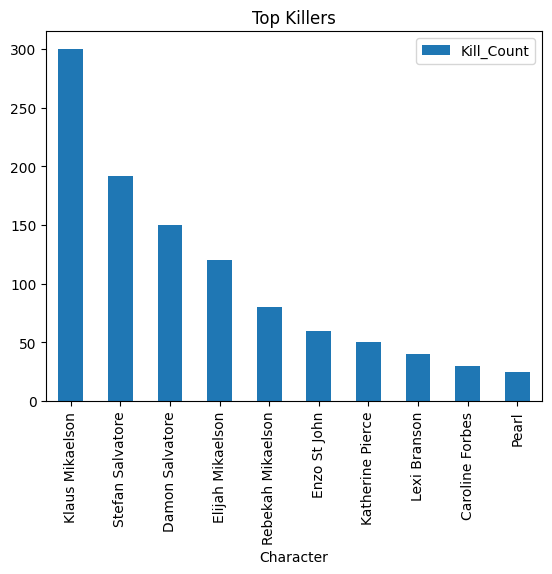

In [14]:
#Highest kill count
df.sort_values(by="Kill_Count", ascending=False).head()

import matplotlib.pyplot as plt

df.sort_values(by="Kill_Count", ascending=False).head(10).plot(
    x="Character", y="Kill_Count", kind="bar"
)

plt.title("Top Killers")
plt.show()

In [15]:
#Specie that died most
df["Species"].value_counts()

,count
Species,
Vampire,29
Werewolf,28
Human,27
Witch,21
Human/Vampire,3
Original Vampire,3
Human/Hunter,1
Werewolf/Vampire,1


In [16]:
#Most revived character
df.sort_values(by="Revived_Count", ascending=False).head()

,Character,Species,Intro_Season,Death_Season,Revived_Count,Killer,Cause_of_Death,Method,Timeline,Kill_Count,Life_Expectancy
8,Jeremy Gilbert,Human/Hunter,1,5,3,Katherine Pierce,Neck Snap,Physical,Present,10,4
7,Alaric Saltzman,Human/Vampire,1,3,2,Klaus Mikaelson,Stab,Physical,Present,25,2
3,Bonnie Bennett,Witch,1,4,2,Silas,Overuse Of Magic,Magic,Present,20,3
0,Elena Gilbert,Human/Vampire,1,6,1,Kai Parker,Magic Link Death,Magic,Present,5,5
6,Tyler Lockwood,Werewolf/Vampire,1,8,1,Damon Salvatore,Neck Snap,Physical,Present,15,7


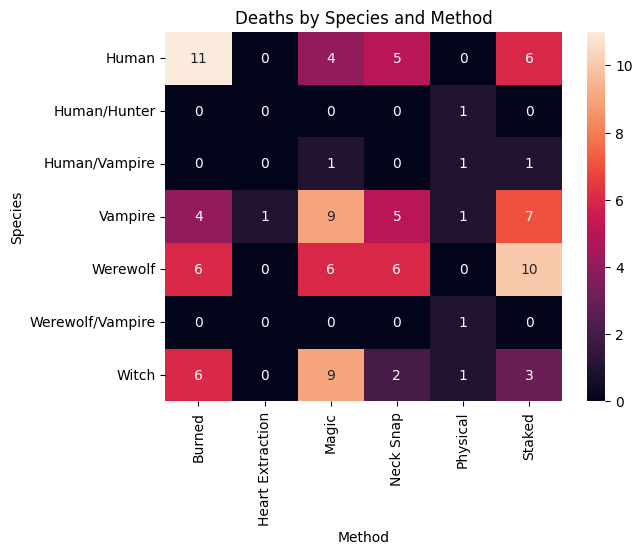

In [17]:
#Heatmap
import seaborn as sns

pivot = pd.crosstab(df["Species"], df["Method"])
sns.heatmap(pivot, annot=True)

plt.title("Deaths by Species and Method")
plt.show()

In [18]:
#Kill count list

import plotly.express as px

kill_map = df.groupby("Killer")["Character"].apply(list).to_dict()

killer_df = df.groupby("Killer")["Character"].count().reset_index()
killer_df.columns = ["Killer", "Kill_Count"]

killer_df["Victims"] = killer_df["Killer"].apply(
    lambda x: ", ".join(kill_map.get(x, []))
)

fig = px.bar(
    killer_df.sort_values(by="Kill_Count", ascending=False).head(10),
    x="Killer",
    y="Kill_Count",
    hover_data=["Victims"],
    title="Kill Count (Hover to See Victims)"
)

fig.show()